# Day 11: TensorRT-LLM — Compilation & Plugin System
> *100 Days of Inference* | Layer: **Runtime** | Book: *Inference Engineering* Ch 4.3.3 (pp. 109–111)

**Prerequisite:** Day 10 (SGLang)

**Goal:** Understand why TensorRT-LLM achieves highest performance among inference engines, how compilation works, and when to use it.

## What problem does this solve?

vLLM and SGLang are general-purpose — they support many models and hardware configurations. Generality costs performance: supporting every configuration means you can't fully optimize for any specific one.

TensorRT-LLM takes the opposite approach: narrow focus on NVIDIA GPUs, manual kernel selection, closed-source NVIDIA-internal kernels not available elsewhere. The tradeoff: harder to use, but best-in-class performance on supported configurations.

**Infrastructure analogy:** vLLM and SGLang are like `nginx` — general-purpose, runs anywhere, good performance. TensorRT-LLM is like hand-tuned assembly for a specific CPU — maximum performance, but requires expertise and is architecture-specific.

## Concept Overview

**TensorRT-LLM** is NVIDIA's open-source inference engine. Important naming note:
- **V0 (0.X.Y):** Older version built on TensorRT (the original graph compiler)
- **V1 (1.X.Y):** Modern version based on PyTorch directly — no TensorRT dependency

Despite the name change, TensorRT-LLM V1 still offers the best performance because:
1. **NVIDIA-internal kernels:** Access to hand-tuned, sometimes closed-source kernels for Hopper and Blackwell
2. **In-flight batching:** Token-level continuous batching with hardware-specific optimizations
3. **Maximum quantization support:** Best FP8, INT8, INT4 support via NVFP4 and other NVIDIA-specific formats

The configuration model: TensorRT-LLM uses a `config.yaml` for deep customization, in addition to CLI flags.

**When to use TensorRT-LLM:**
- Running on H100 or later (Hopper+)
- Need maximum possible performance
- Willing to invest in configuration and tuning
- Planning to use NVIDIA Dynamo for orchestration

In [1]:
!pip install -q numpy matplotlib torch 2>/dev/null
import numpy as np
import matplotlib.pyplot as plt
import torch
import time

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GB10
GPU Memory: 128.5 GB


## Part 1: The Compilation Advantage

Compilation in the inference context means: given a specific model architecture AND specific hardware, generate the most efficient execution plan possible.

What compilation does:
1. **Static shape specialization:** If you know the batch size, sequence length, and hardware, you can pick kernels optimized for those exact dimensions
2. **Kernel selection:** Choose the best GEMM kernel for each matrix size
3. **Kernel fusion:** Identify operations that can be merged
4. **Memory planning:** Pre-allocate buffers with exact sizes, no runtime allocation

The cost: compilation takes time (minutes for large models). The benefit: faster inference for the life of the deployment.

**Infrastructure analogy:** JIT compilation (PyTorch eager) vs. AOT compilation (TensorRT-LLM). JIT compiles each operation as it's called — flexible but overhead per call. AOT compiles everything upfront — higher startup cost, faster at runtime.

In [3]:
# Demonstrate compilation speedup using torch.compile as a proxy
# TensorRT-LLM achieves much larger speedups with its proprietary kernels,
# but torch.compile shows the same principle.

import torch
import torch.nn as nn
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Free any leaked VRAM from prior cells or reruns
if device.type == 'cuda':
    torch.cuda.empty_cache()

class TransformerLayer(nn.Module):
    """A typical transformer layer (attention + FFN + norms)."""
    def __init__(self, hidden=2048, heads=16, ffn_mult=4):
        super().__init__()
        self.hidden = hidden
        d_head = hidden // heads

        # Attention projections
        self.qkv = nn.Linear(hidden, 3 * hidden, bias=False)
        self.out = nn.Linear(hidden, hidden, bias=False)

        # FFN (SwiGLU style)
        ffn = hidden * ffn_mult
        self.gate = nn.Linear(hidden, ffn, bias=False)
        self.up = nn.Linear(hidden, ffn, bias=False)
        self.down = nn.Linear(ffn, hidden, bias=False)

        # Norms
        self.norm1 = nn.RMSNorm(hidden) if hasattr(nn, 'RMSNorm') else nn.LayerNorm(hidden)
        self.norm2 = nn.RMSNorm(hidden) if hasattr(nn, 'RMSNorm') else nn.LayerNorm(hidden)

    def forward(self, x):
        B, T, C = x.shape
        # Attention (simplified - no actual masking for benchmark purity)
        normed = self.norm1(x)
        qkv = self.qkv(normed).reshape(B, T, 3, C).permute(2, 0, 1, 3)
        Q, K, V = qkv[0], qkv[1], qkv[2]
        attn = torch.nn.functional.scaled_dot_product_attention(Q, K, V)
        attn_out = self.out(attn.reshape(B, T, C))
        x = x + attn_out

        # FFN
        normed2 = self.norm2(x)
        ffn_out = self.down(torch.nn.functional.silu(self.gate(normed2)) * self.up(normed2))
        return x + ffn_out

model = TransformerLayer(hidden=2048, heads=16).to(device=device, dtype=torch.float16)

def bench(fn, x, n=50):
    with torch.no_grad():
        for _ in range(5): fn(x)
        if device.type == 'cuda': torch.cuda.synchronize()
        t = time.perf_counter()
        for _ in range(n):
            fn(x)
            if device.type == 'cuda': torch.cuda.synchronize()
    return (time.perf_counter() - t) / n * 1000

# Test across different batch/sequence configurations
configs = [
    ("Decode: batch=1, seq=1",   1,   1),
    ("Decode: batch=8, seq=1",   8,   1),
    ("Prefill: batch=1, seq=512", 1,  512),
    ("Prefill: batch=4, seq=256", 4,  256),
]

print("Transformer layer benchmark (eager vs compiled)")
print(f"{'Config':<30} {'Eager (ms)':>11} {'Compiled (ms)':>14} {'Speedup':>9}")
print("-" * 70)

for label, B, T in configs:
    x = torch.randn(B, T, 2048, dtype=torch.float16, device=device)
    t_eager = bench(model, x)

    try:
        model_c = torch.compile(model, mode='reduce-overhead')
        with torch.no_grad(): _ = model_c(x)  # compile
        t_compiled = bench(model_c, x)
        speedup = t_eager / t_compiled
        print(f"{label:<30} {t_eager:>9.3f}ms {t_compiled:>12.3f}ms {speedup:>8.2f}x")
    except Exception:
        print(f"{label:<30} {t_eager:>9.3f}ms {'N/A':>12} {'N/A':>8}")

# Clean up to free VRAM for subsequent cells
del model, x
if device.type == 'cuda':
    torch.cuda.empty_cache()

print()
print("Note: TensorRT-LLM achieves larger speedups via NVIDIA proprietary kernels")
print("(e.g. FP8 GEMM on Hopper), not available through torch.compile.")

Transformer layer benchmark (eager vs compiled)
Config                          Eager (ms)  Compiled (ms)   Speedup
----------------------------------------------------------------------
Decode: batch=1, seq=1             1.011ms        1.093ms     0.92x
Decode: batch=8, seq=1             1.105ms        0.942ms     1.17x
Prefill: batch=1, seq=512          1.902ms        1.580ms     1.20x
Prefill: batch=4, seq=256          3.211ms        2.932ms     1.10x

Note: TensorRT-LLM achieves larger speedups via NVIDIA proprietary kernels
(e.g. FP8 GEMM on Hopper), not available through torch.compile.


## Part 2: The Plugin System — Custom Kernel Integration

TensorRT-LLM's plugin system allows injecting custom CUDA kernels into the inference pipeline. This is how NVIDIA integrates its proprietary kernels:

- **Flash Attention kernel:** Custom tiled attention implementation for each GPU architecture
- **FP8 GEMM kernels:** Exploits Hopper's native FP8 Tensor Cores
- **Fused QKV projections:** Compute Q, K, V in a single kernel pass
- **Fused MLP:** Gate + up + activation + down in one kernel

This is why TensorRT-LLM can outperform open-source kernels — NVIDIA's internal engineers have access to hardware documentation and early silicon not publicly available.

**Infrastructure analogy:** The plugin system is like a driver module in Linux. The kernel (TensorRT-LLM) provides standard interfaces; plugins are loadable modules that implement those interfaces with hardware-optimized code.

In [4]:
# Custom GEMM (General Matrix Multiply) kernel using Triton
# This demonstrates the same tiling approach that TensorRT-LLM's
# proprietary kernels use — but those go further with architecture-specific
# instructions (e.g. wgmma on Hopper for FP8) not exposed publicly.

import torch
import triton
import triton.language as tl

@triton.jit
def gemm_kernel(
    A_ptr, B_ptr, C_ptr,
    M, N, K,
    stride_am, stride_ak,
    stride_bk, stride_bn,
    stride_cm, stride_cn,
    BLOCK_M: tl.constexpr, BLOCK_N: tl.constexpr, BLOCK_K: tl.constexpr,
):
    """Tiled GEMM: C[M,N] = A[M,K] @ B[K,N]
    
    Each program instance computes one BLOCK_M x BLOCK_N output tile.
    The K dimension is accumulated in BLOCK_K steps.
    
    Memory hierarchy mapping:
      - acc (register file): BLOCK_M x BLOCK_N accumulator per thread block
      - a_tile / b_tile (shared memory → registers): loaded per K-step
      - A_ptr / B_ptr (HBM): global memory, streamed in BLOCK_K strips
    """
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)

    # Block start offsets
    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_n = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)
    offs_k = tl.arange(0, BLOCK_K)

    # Pointers to first tiles of A and B
    a_ptrs = A_ptr + offs_m[:, None] * stride_am + offs_k[None, :] * stride_ak
    b_ptrs = B_ptr + offs_k[:, None] * stride_bk + offs_n[None, :] * stride_bn

    # Accumulate in FP32 for numerical stability (same as FP8 kernels —
    # FP8 inputs, FP32 accumulation, downcast on store)
    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)

    # Loop over K dimension in BLOCK_K tiles
    for k_start in range(0, K, BLOCK_K):
        a_tile = tl.load(a_ptrs, mask=(offs_m[:, None] < M) & (offs_k[None, :] < K))
        b_tile = tl.load(b_ptrs, mask=(offs_k[:, None] < K) & (offs_n[None, :] < N))
        acc += tl.dot(a_tile, b_tile)
        a_ptrs += BLOCK_K * stride_ak
        b_ptrs += BLOCK_K * stride_bk
        offs_k += BLOCK_K

    # Write result — downcast from FP32 accumulator to FP16
    c_ptrs = C_ptr + offs_m[:, None] * stride_cm + offs_n[None, :] * stride_cn
    mask = (offs_m[:, None] < M) & (offs_n[None, :] < N)
    tl.store(c_ptrs, acc.to(tl.float16), mask=mask)


def triton_gemm(A, B):
    """Launch the custom GEMM kernel with fixed tile sizes."""
    M, K = A.shape
    K2, N = B.shape
    assert K == K2
    C = torch.empty(M, N, device=A.device, dtype=A.dtype)
    BLOCK_M, BLOCK_N, BLOCK_K = 64, 64, 32
    grid = (triton.cdiv(M, BLOCK_M), triton.cdiv(N, BLOCK_N))
    gemm_kernel[grid](
        A, B, C,
        M, N, K,
        A.stride(0), A.stride(1),
        B.stride(0), B.stride(1),
        C.stride(0), C.stride(1),
        BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N, BLOCK_K=BLOCK_K,
    )
    return C


# --- Benchmark: custom Triton GEMM vs cuBLAS (torch.matmul) ---
# 4096x4096 is a typical LLM weight matrix dimension
M, N, K = 4096, 4096, 4096
A = torch.randn(M, K, device='cuda', dtype=torch.float16)
B = torch.randn(K, N, device='cuda', dtype=torch.float16)

# Correctness check
C_triton = triton_gemm(A, B)
C_torch  = A @ B
print(f"Max error vs cuBLAS: {(C_triton - C_torch).abs().max().item():.4f}")

# Benchmark
def bench_gemm(fn, n=50):
    for _ in range(5): fn()
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n):
        fn()
    torch.cuda.synchronize()
    return (time.perf_counter() - t0) / n * 1000

t_cublas = bench_gemm(lambda: A @ B)
t_triton = bench_gemm(lambda: triton_gemm(A, B))

tflops_cublas = 2 * M * N * K / (t_cublas / 1000) / 1e12
tflops_triton = 2 * M * N * K / (t_triton / 1000) / 1e12

print(f"\n{'Kernel':<22} {'Time (ms)':>10} {'TFLOPS':>10}")
print("-" * 44)
print(f"{'cuBLAS (torch.matmul)':<22} {t_cublas:>10.3f} {tflops_cublas:>10.1f}")
print(f"{'Triton custom GEMM':<22} {t_triton:>10.3f} {tflops_triton:>10.1f}")
print(f"\ncuBLAS is the baseline. NVIDIA's proprietary FP8 GEMM kernels")
print(f"beat cuBLAS by ~2x on Hopper via FP8 Tensor Core instructions")
print(f"(wgmma) not exposed in the public CUDA toolkit — that gap is")
print(f"the TensorRT-LLM plugin advantage.")

Max error vs cuBLAS: 0.0000

Kernel                  Time (ms)     TFLOPS
--------------------------------------------
cuBLAS (torch.matmul)       1.573       87.3
Triton custom GEMM          3.313       41.5

cuBLAS is the baseline. NVIDIA's proprietary FP8 GEMM kernels
beat cuBLAS by ~2x on Hopper via FP8 Tensor Core instructions
(wgmma) not exposed in the public CUDA toolkit — that gap is
the TensorRT-LLM plugin advantage.


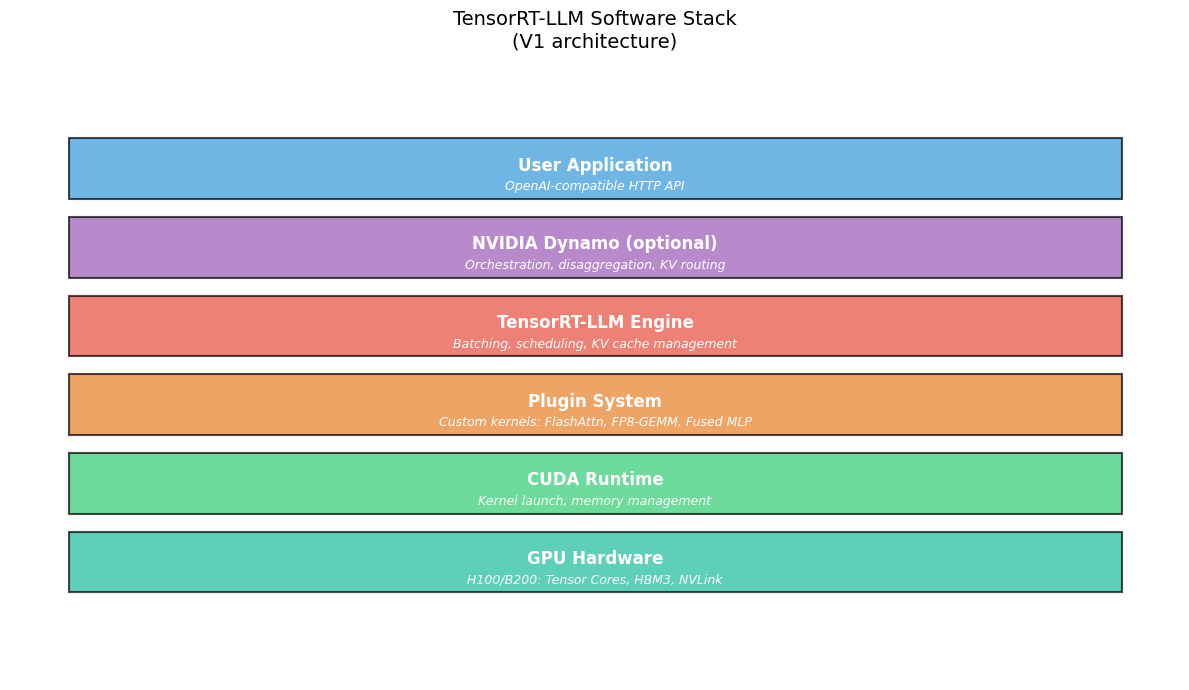


Inference engine comparison (from the book):
Dimension                  vLLM     SGLang    TRT-LLM
-------------------------------------------------------
Performance                Good       Good       Best
Ease of use                Easy       Easy       Hard
Model support              Most       Most       Some
Hardware                GPU/TPU NVIDIA/AMD NVIDIA only
License                  Apache     Apache     Apache


In [5]:
# Visualize the TensorRT-LLM architecture layers

fig, ax = plt.subplots(figsize=(12, 7))

layers = [
    ("User Application",        0.85, '#3498db', 'OpenAI-compatible HTTP API'),
    ("NVIDIA Dynamo (optional)", 0.72, '#9b59b6', 'Orchestration, disaggregation, KV routing'),
    ("TensorRT-LLM Engine",     0.59, '#e74c3c', 'Batching, scheduling, KV cache management'),
    ("Plugin System",           0.46, '#e67e22', 'Custom kernels: FlashAttn, FP8-GEMM, Fused MLP'),
    ("CUDA Runtime",            0.33, '#2ecc71', 'Kernel launch, memory management'),
    ("GPU Hardware",            0.20, '#1abc9c', 'H100/B200: Tensor Cores, HBM3, NVLink'),
]

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

for label, y_center, color, description in layers:
    rect = plt.Rectangle((0.05, y_center - 0.055), 0.9, 0.1,
                         facecolor=color, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(0.5, y_center, label, ha='center', va='center', fontsize=12,
            fontweight='bold', color='white')
    ax.text(0.5, y_center - 0.035, description, ha='center', va='center',
            fontsize=9, color='white', style='italic')

ax.set_title('TensorRT-LLM Software Stack\n(V1 architecture)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Compare inference engines
print("\nInference engine comparison (from the book):")
print(f"{'Dimension':<20} {'vLLM':>10} {'SGLang':>10} {'TRT-LLM':>10}")
print("-" * 55)
comparisons = [
    ("Performance",    "Good",   "Good",  "Best"),
    ("Ease of use",    "Easy",   "Easy",  "Hard"),
    ("Model support",  "Most",   "Most",  "Some"),
    ("Hardware",       "GPU/TPU","NVIDIA/AMD","NVIDIA only"),
    ("License",        "Apache", "Apache","Apache"),
]
for dim, v, s, t in comparisons:
    print(f"{dim:<20} {v:>10} {s:>10} {t:>10}")

## Part 3: In-Flight Batching (Continuous Batching in TRT-LLM)

TensorRT-LLM calls their continuous batching implementation **in-flight batching**. The concept is the same as vLLM's continuous batching (Day 09), but the implementation is tuned for NVIDIA hardware.

Key configuration in TRT-LLM:
```yaml
max_batch_size: 1024      # max concurrent sequences
max_num_tokens: 3200      # total tokens in flight across all sequences
kv_cache_free_gpu_memory_fraction: 0.8  # fraction of free VRAM for KV cache
```

The `max_num_tokens` parameter is the critical tuning knob: it determines how much compute happens per step. Too low: GPU underutilized. Too high: OOM on long sequences.

max_tokens_per_step | Total time (ms) | Throughput (tok/s)
-------------------------------------------------------
                   1 |           55040 |                200
                   2 |           27740 |                397
                   4 |           14090 |                781
                   8 |            7195 |               1530
                  16 |            3960 |               2780
                  32 |            2270 |               4849
                  64 |            1450 |               7592
                 128 |            1000 |              11008
                 256 |            1000 |              11008
                 512 |            1000 |              11008


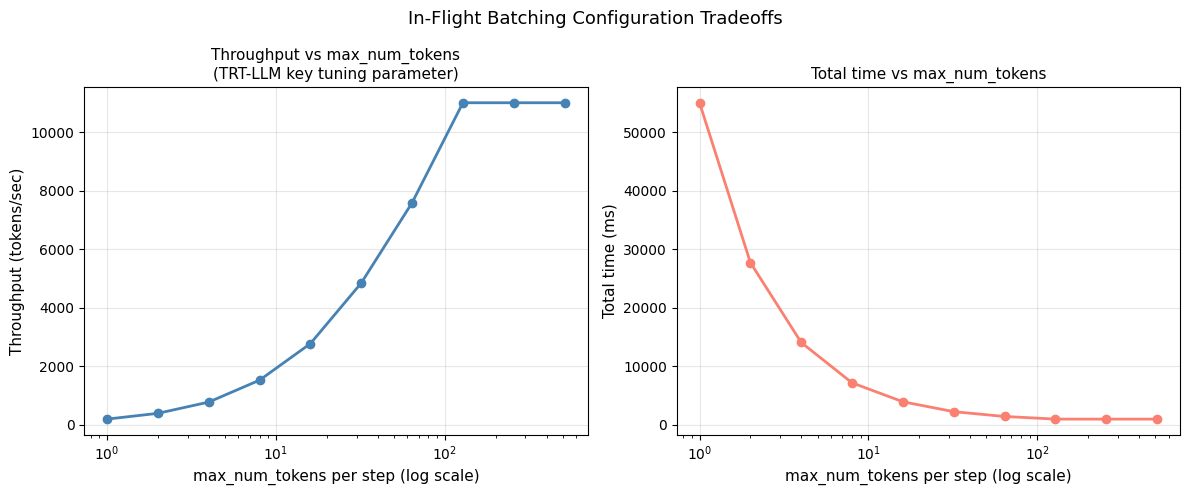

In [6]:
# Model the relationship between max_num_tokens and throughput
# This simulates the TRT-LLM scheduling decision

import matplotlib.pyplot as plt

def simulate_inflight_batching(max_tokens_per_step, requests, ms_per_token=5):
    """
    max_tokens_per_step: total tokens processed per forward pass
    requests: list of (seq_len,) tuples
    """
    import queue
    req_queue = list(enumerate(requests))  # (id, length)
    active = []  # [(remaining_len, req_id)]
    total_time_ms = 0
    total_tokens = sum(r for r in requests)

    while req_queue or active:
        # Fill batch up to max_tokens_per_step
        tokens_this_step = sum(1 for _ in active)  # 1 token per active request

        while req_queue and tokens_this_step < max_tokens_per_step:
            req_id, length = req_queue.pop(0)
            active.append([length, req_id])
            tokens_this_step += 1

        if not active:
            break

        # Time for this step proportional to batch size
        # (simplified: linear scaling, real GPU is sublinear due to batching efficiency)
        total_time_ms += ms_per_token

        # Generate one token per active request
        active = [[r - 1, rid] for r, rid in active]
        active = [[r, rid] for r, rid in active if r > 0]

    return total_time_ms, total_tokens / total_time_ms * 1000

import random
random.seed(42)
requests = [random.randint(20, 200) for _ in range(100)]

max_token_values = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
throughputs = []
times = []

print(f"max_tokens_per_step | Total time (ms) | Throughput (tok/s)")
print("-" * 55)
for max_tok in max_token_values:
    t, tps = simulate_inflight_batching(max_tok, requests)
    throughputs.append(tps)
    times.append(t)
    print(f"{max_tok:>20} | {t:>15.0f} | {tps:>18.0f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.semilogx(max_token_values, throughputs, 'o-', color='steelblue', linewidth=2)
ax1.set_xlabel('max_num_tokens per step (log scale)', fontsize=11)
ax1.set_ylabel('Throughput (tokens/sec)', fontsize=11)
ax1.set_title('Throughput vs max_num_tokens\n(TRT-LLM key tuning parameter)', fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.semilogx(max_token_values, times, 'o-', color='salmon', linewidth=2)
ax2.set_xlabel('max_num_tokens per step (log scale)', fontsize=11)
ax2.set_ylabel('Total time (ms)', fontsize=11)
ax2.set_title('Total time vs max_num_tokens', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle('In-Flight Batching Configuration Tradeoffs', fontsize=13)
plt.tight_layout()
plt.show()

## Try These Experiments

1. **Compilation time estimate:** TensorRT-LLM compilation for a 7B model takes approximately 5-10 minutes. For a cold start without cached engines, this adds directly to startup time. Calculate: if you're running 10 replicas that all need to restart simultaneously (e.g., rolling update), what is the total fleet startup time? How does caching compiled engines help?

2. **max_num_tokens sensitivity:** Modify the simulation to have a non-uniform distribution of request lengths (10% of requests are 10x longer). How does this affect the optimal `max_num_tokens` setting?

3. **Plugin performance model:** Look up the FP8 GEMM performance on H100 vs FP16 (roughly 2x faster for FP8 due to 2x more compute per clock). For a 70B model inference, how much of the total latency comes from GEMM operations? What would a 2x GEMM speedup mean for end-to-end latency?

## Key Takeaways

- TensorRT-LLM achieves best-in-class performance via NVIDIA proprietary kernels (especially for FP8 on Hopper) and hardware-specific kernel selection.
- The plugin system enables injecting custom kernels into the standard pipeline — the same architecture that allows NVIDIA to keep their best kernels internal.
- Use TRT-LLM when you're on H100+ hardware, need maximum performance, and are willing to invest in configuration. For most teams, vLLM or SGLang offers better developer velocity.
- `max_num_tokens` (in-flight batching window) is the primary throughput tuning knob — tune it for your workload's sequence length distribution.
- **What's next:** Day 12 — NVIDIA Dynamo: the orchestration layer above inference engines for disaggregated serving.

## References
- *Inference Engineering* Ch 4.3.3 (pp. 109–111) — TensorRT-LLM